# I. Phân tích chiến lược quảng cáo và Logistic

**[Q3]**: Hai mục tiêu chính cần xác định:
- Quảng cáo tác động lên doanh số như thế nào? Liệu các sản phẩm mới có cần sử dụng quảng cáo để thúc đẩy bán hàng trong giai đoạn đầu hay không?
- Vị trí shop có ảnh hưởng đến hiệu quả bán hàng không (đặc biệt là nước ngoài) và freeship có giúp giảm bất lợi về khoảng cách không?

# II. Hướng giải quyết

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
sns.set(style="whitegrid")
import re

In [3]:
df = pd.read_json("../../Data/Shopee/cleaned_shopee_data.json")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44937 entries, 0 to 44936
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Danh_muc_chinh       44937 non-null  object 
 1   Danh_muc_phu         44937 non-null  object 
 2   Ma_san_pham          44937 non-null  int64  
 3   Ma_cua_hang          44937 non-null  int64  
 4   Ten_san_pham         44937 non-null  object 
 5   Gia                  44937 non-null  int64  
 6   Gia_goc              44937 non-null  int64  
 7   Phan_tram_giam_gia   44937 non-null  float64
 8   Diem_hai_long        44937 non-null  float64
 9   So_danh_gia          44937 non-null  int64  
 10  Doanh_so_thang       44937 non-null  int64  
 11  Doanh_so_tong        44937 non-null  int64  
 12  Luot_thich           44937 non-null  int64  
 13  Dia_diem_cua_hang    44937 non-null  object 
 14  La_mall              44937 non-null  bool   
 15  Da_xac_thuc          44937 non-null 

## 1. Mục tiêu 1

Câu hỏi cần giải quyết là: "Quảng cáo tác động lên doanh số như thế nào? Liệu các sản phẩm mới có cần sử dụng quảng cáo để thúc đẩy bán hàng trong giai đoạn đầu hay không?"

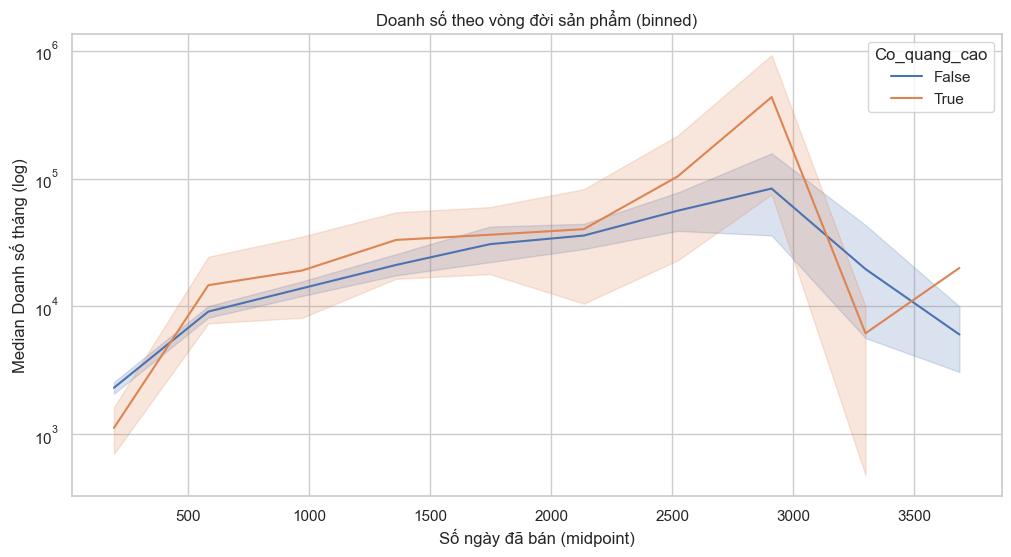

In [18]:
# Tạo bin
df['age_bin'] = pd.cut(df['So_ngay_da_ban'], bins=10)

# Lấy midpoint của mỗi bin
df['age_bin_mid'] = df['age_bin'].apply(lambda x: x.mid)

plt.figure(figsize=(12,6))

sns.lineplot(
    x='age_bin_mid',
    y='Doanh_so_tong',
    hue='Co_quang_cao',
    data=df,
    estimator='mean'
)

plt.yscale('log')
plt.title('Doanh số theo vòng đời sản phẩm (binned)')
plt.xlabel('Số ngày đã bán (midpoint)')
plt.ylabel('Median Doanh số tháng (log)')
plt.show()